In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [4]:
df = pd.read_excel('nutrients_2018dfo.xlsx',parse_dates=['dtUTC'],index_col=0)
#df = pd.read_csv('PugetSound_2018.csv',parse_dates=['Sample_Date'])
#df = df.drop_duplicates(subset=['Depth', 'folder_day'])
#df = df[(df['Sample_Date']>=dt.datetime(2018,2,27))&(df['Sample_Date']<=dt.datetime(2018,7,1))]

In [5]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [6]:
def make_filename(path_run,folder, var='biol_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict"""
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(prefix, fname[0])

In [7]:
mask = xr.open_dataset('/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc')

In [8]:
df['folder_day'] = df['dtUTC'].dt.strftime('%d%b%y').str.lower()
jj = []
ii = []
dd = []
za = []
zb = []
for row in df.itertuples(index=False):
    j,i = finder(row.Lat,row.Lon)
    jj.append(j)
    ii.append(i)
    if row.Depth >= 0 and j>0 and row.Depth != 0.5:
        diff = mask.gdept_0[0,:,j,i].values - row.Depth
        dd.append(diff[diff<0].argmax())
        za.append(mask.gdept_0[0,:,j,i].values[dd[-1]])
        zb.append(mask.gdept_0[0,:,j,i].values[dd[-1]+1])
    elif row.Depth == 0.5 and j>0:
        dd.append(0)
        za.append(0)
        zb.append(1)
    else:
        dd.append('NaN')
        za.append('NaN')
        zb.append('NaN')
        
df['j'] = jj
df['i'] = ii
df['k_above'] = dd
df['z_above'] = za
df['z_bellow'] = zb

In [9]:
def interp_depth(N_shallow, N_deep, z_shallow, z_deep, z_obs):
    return N_shallow + (N_deep - N_shallow) * (z_obs - z_shallow) / (z_deep - z_shallow)

In [10]:
# path = '/home/jvalenti/scratch/run_SHEM/SSBase/'
# N_model = np.full(len(df), np.nan)

# for folder_day, group in df.groupby('folder_day'):
#     try:
#         fn = make_filename(path, folder_day)
#     except FileNotFoundError:
#         continue
#     with xr.open_dataset(fn, engine='h5netcdf') as ds:
#         var = ds['dissolved_oxygen'].isel(time_counter=0)
#         for idx, row in group.iterrows():
#             if row.k_above == 'NaN':
#                 continue
#             ab = var.isel(deptht=slice(row.k_above, row.k_above + 2),y=row.j,x=row.i).values
#             N_model[idx] = interp_depth(ab[0], ab[1],row.z_above, row.z_bellow,row.Depth)
#             print(N_model[idx])
# df['N_model'] = N_model

In [11]:
runs = ['SSBase','SHEM18','diat_pref','exc_hbac','exc_hbac_2','growth_flag','growth_flag_2','mort_hbac','pred_flag','remin','remin2','predmine','mort_hbac_2','remin2_l']

In [12]:
# name = remin_l
# df = pd.read_excel(f'DO_puget_{name}.xlsx',parse_dates=['Sample_Date'],index_col=0)
# df.to_csv(f'DO_puget_{name}.csv')

In [13]:
# dfloc = pd.read_csv(f'/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/PugetSound_2018.csv',parse_dates=['Sample_Date'],index_col=0)
# dfloc = dfloc[dfloc['Sample_Date']>=dt.datetime(2018,2,27)].reset_index(drop=True)
# dfloc.Locator

In [14]:
dft = pd.read_csv(f'DO_puget_remin.csv',parse_dates=['Sample_Date'],index_col=0)

In [15]:
dft2 = dft[dft.Sample_Date>=dt.datetime(2018,2,27)]
dft3 = dft2[dft2.N_model>0]
dft3.N_model.describe()

count    42285.000000
mean       224.642977
std         35.497357
min        166.363495
25%        205.154007
50%        216.881760
75%        230.436600
max        398.677521
Name: N_model, dtype: float64

In [16]:
dft2.DO.min()

6.2446

In [17]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()

    return rmse_val, bias, WI

mask_N = (dft.N_model!= 0) & (~dft.Nitrate.isna()) & (~dft.N_model.isna())
rmse,bias, WI = calculate_rmse_bias(dft.Nitrate[mask_N]*71.39, dft.N_model[mask_N])

print(f"RMSE: {rmse}")
print(f"Bias: {bias}")
print(f"Willmott Index: {WI}")

RMSE: 206.35807307424062
Bias: 202.65786359392033
Willmott Index: 0.027762008457642096


In [18]:
coords=  xr.open_dataset('~/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)


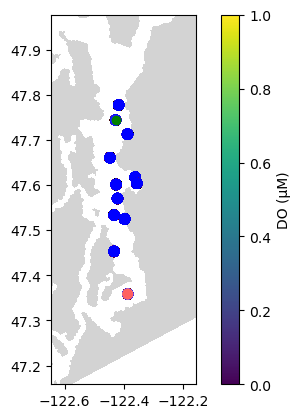

In [19]:
mask_N = (dft.N_model!= 0) & (~dft.DO.isna())
fig, ax = plt.subplots()
plt.contourf(coords.nav_lon, coords.nav_lat, mask.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='lightgray')
plt.scatter(dft.Longitude[mask_N],dft.Latitude[mask_N], c=dft.DO[mask_N]*31.25-dft.N_model[mask_N], s=50, cmap='bwr', vmin=-10, vmax=10)
plt.scatter(coords.nav_lon[103,253], coords.nav_lat[103,253],color='green')
plt.colorbar(label='DO (µM)')
plt.xlim(min(dft.Longitude[mask_N])-0.2, max(dft.Longitude[mask_N])+0.2)
plt.ylim(min(dft.Latitude[mask_N])-0.2, max(dft.Latitude[mask_N])+0.2)
f = 1.0/np.cos(49*np.pi/180)
plt.gca().set_aspect(f)

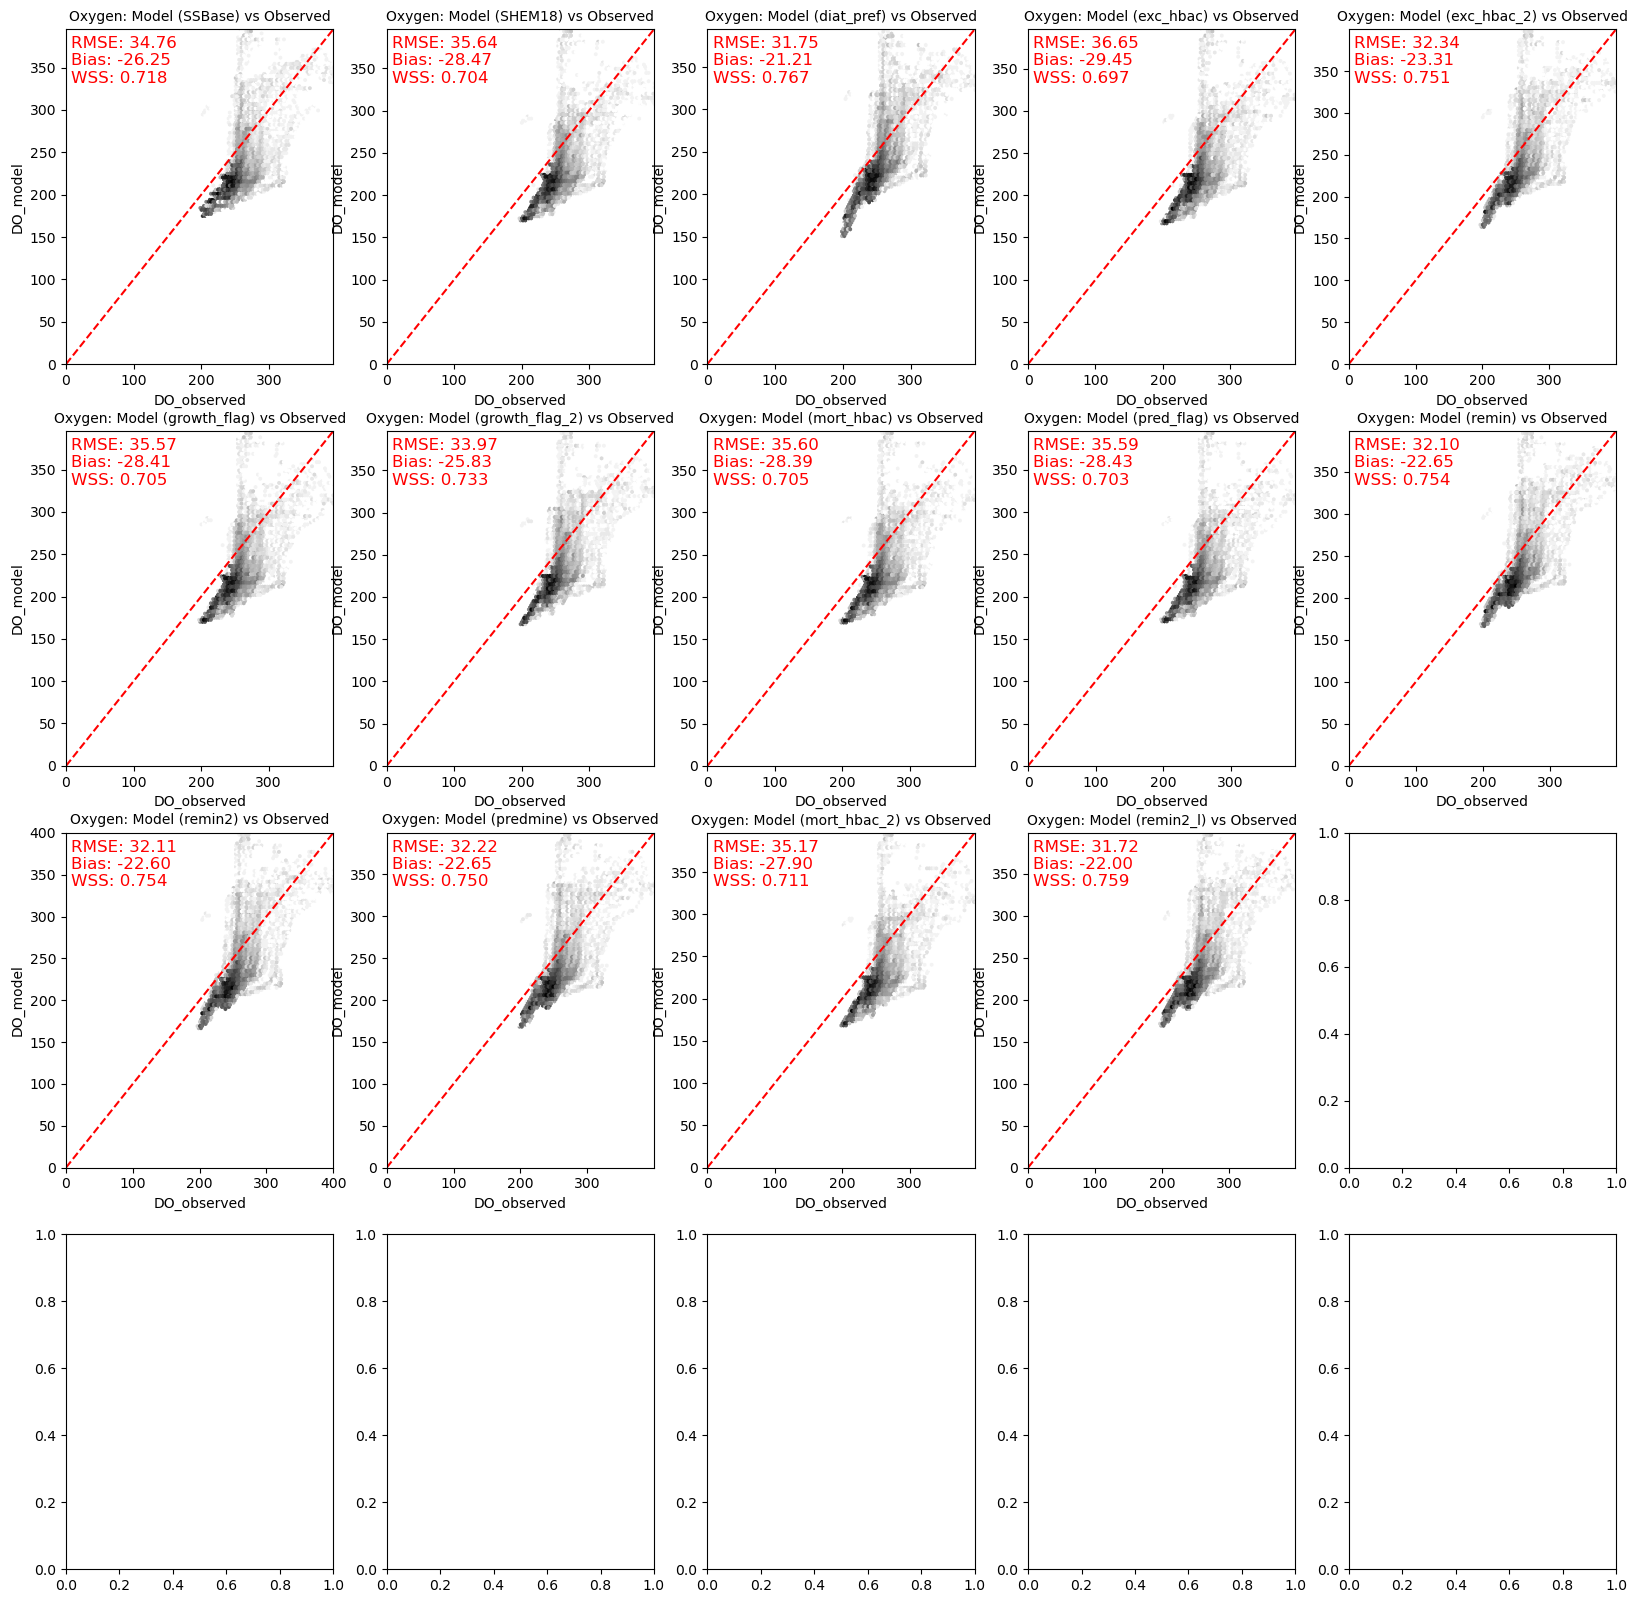

In [20]:
import matplotlib
fig_0,axs_0 = plt.subplots(4,5, figsize=(20,20))
axs_0 = axs_0.flatten() 
for i,name in enumerate(runs):
    dft = pd.read_csv(f'DO_puget_{name}.csv',parse_dates=['Sample_Date'])
    #dft.Oxygen_Dissolved = dft.Oxygen_Dissolved*gsw.rho(dft.AbsSal, dft.ConsT, dft.Pressure)/1000
    dft = dft[(dft['Sample_Date']>=dt.datetime(2018,2,27))&(dft['Sample_Date']<=dt.datetime(2018,7,1))]
    mask_N = (dft.N_model> 0) & (~dft.DO.isna())
    rmse,bias,WI = calculate_rmse_bias(dft.DO[mask_N]*31.25, dft.N_model[mask_N])
    axs_0[i].hexbin(dft.DO[mask_N]*31.25,dft.N_model[mask_N], gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    axs_0[i].set_xlabel('DO_observed')
    axs_0[i].set_ylabel('DO_model')
    axs_0[i].set_title(f'Oxygen: Model ({name}) vs Observed')
    axs_0[i].plot(np.linspace(0, max(dft.N_model[mask_N].max(), dft.DO[mask_N].max()), 100), np.linspace(0, max(dft.N_model[mask_N].max(), dft.DO[mask_N].max()), 100), 'r--') 
    axs_0[i].set_xlim(0, max(dft.N_model[mask_N].max(), dft.DO[mask_N].max()))
    axs_0[i].set_ylim(0, max(dft.N_model[mask_N].max(), dft.DO[mask_N].max()))
    axs_0[i].text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=axs_0[i].transAxes,color='red')

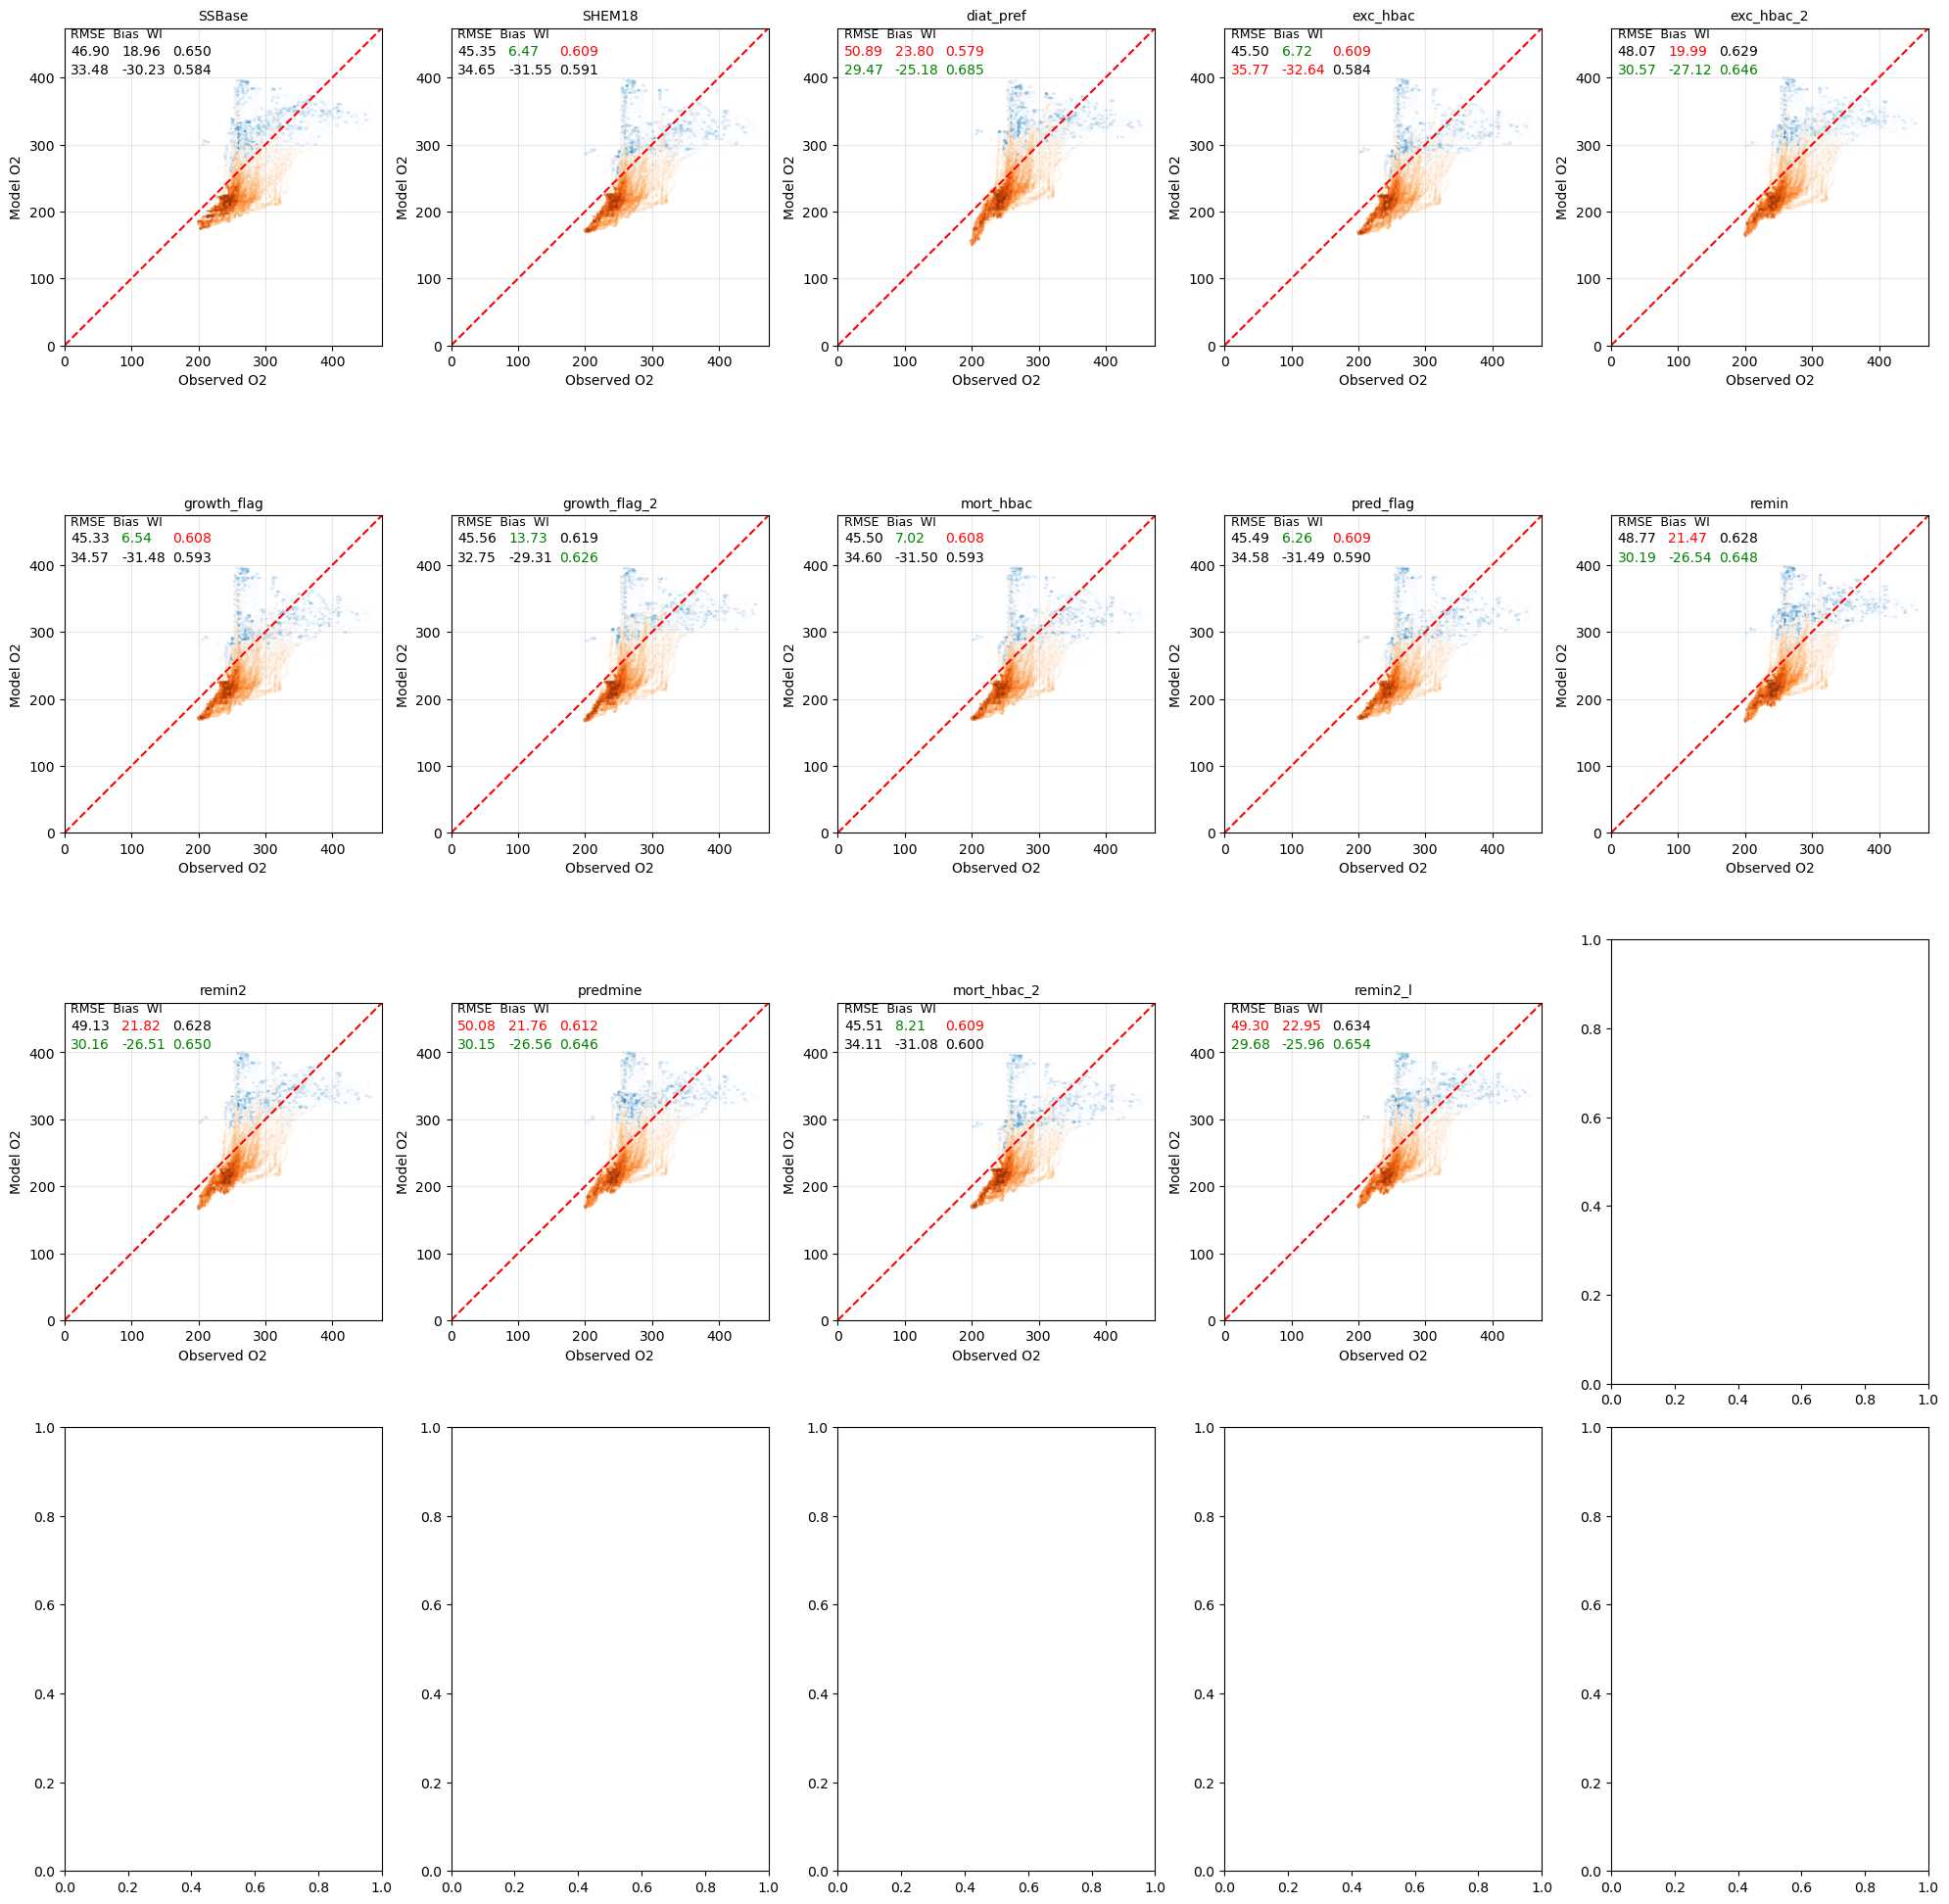

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- SETTINGS ---
depth_limits = [(0, 10), (10, np.inf)]
depth_labels = ["Shallow", "Deep"]
cmaps = ["Blues", "Oranges"]
tol = 0.05 #5%

def valid_mask(df):
    return (df.N_model != 0) & (df.DO.notna()) & (df.N_model.notna())

# --- BASELINE ---
base = pd.read_csv('DO_puget_SSBase.csv', parse_dates=['Sample_Date'])
base = base[(base['Sample_Date']>=dt.datetime(2018,2,27))&(base['Sample_Date']<=dt.datetime(2018,7,1))]
mb = valid_mask(base)

baseline_stats = [
    calculate_rmse_bias(base.DO[m]*31.25, base.N_model[m]) if m.any() else (np.nan, np.nan, np.nan)
    for m in [mb & base.Depth.between(d0, d1, inclusive='left') for d0, d1 in depth_limits]
]

# --- PLOTS ---
fig, axs = plt.subplots(4, 5, figsize=(20, 20))
axs = axs.ravel()

for ax, name in zip(axs, runs):
    df = pd.read_csv(f'DO_puget_{name}.csv', parse_dates=['Sample_Date'])
    df = df[(df['Sample_Date']>=dt.datetime(2018,2,27))&(df['Sample_Date']<=dt.datetime(2018,7,1))]
    m = valid_mask(df)
    stats = []

    for j, ((d0, d1), cmap) in enumerate(zip(depth_limits, cmaps)):
        dm = m & df.Depth.between(d0, d1, inclusive='left')
        if not dm.any():
            stats.append(("—","black","—","black"))
            continue

        hb = ax.hexbin(df.DO[dm]*31.25, df.N_model[dm],
                       gridsize=80, norm=mcolors.LogNorm(),
                       cmap=cmap, alpha=0.6, mincnt=1)

        rmse, bias, WI = calculate_rmse_bias(df.DO[dm]*31.25, df.N_model[dm])
        br, bb, bWI = baseline_stats[j]

        better_rmse = abs(rmse) <= abs(br) - abs(tol*br) 
        better_bias = abs(bias) <= abs(bb) - abs(tol*bb) 
        better_WI = WI >= bWI + tol*bWI 

        stats.append((
            f"{rmse:.2f}", "green" if better_rmse else("black" if abs(rmse) <= abs(br) + abs(tol*br) else "red") ,
            f"{bias:.2f}", "green" if better_bias else("black" if abs(bias) <= abs(bb) + abs(tol*bb) else "red") ,
            f"{WI:.3f}", "green" if better_WI else("black" if WI >= bWI - tol*bWI else "red")
        ))

    if m.any():
        mx = max(df.N_model[m].max(), (df.DO[m]*31.25).max())
        ax.plot([0,mx],[0,mx],'r--')
        ax.set(xlim=(0,mx), ylim=(0,mx), aspect='equal')

    ax.set(title=f"{name}", xlabel="Observed O2", ylabel="Model O2")
    ax.text(0.02,0.97,"RMSE  Bias  WI", transform=ax.transAxes, fontsize=9)

    y = 0.95
    for r, rc, b, bc, w, wc in stats:
        ax.text(0.02,y,r,color=rc,transform=ax.transAxes,va='top')
        ax.text(0.18,y,b,color=bc,transform=ax.transAxes,va='top')
        ax.text(0.34,y,w,color=wc,transform=ax.transAxes,va='top')
        y -= 0.06

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
df_tall = pd.read_csv('ObsModel_202410b_PS_fromJose_20180101_20181231.csv', parse_dates=['dtUTC'], index_col=0)
df_tall = df_tall[(df_tall.index>=dt.datetime(2018,2,27))&(df_tall.index<=dt.datetime(2018,7,1))]

df_tall_base = pd.read_csv('ObsModel_202111_PS_fromJose_20180101_20181231.csv', parse_dates=['dtUTC'], index_col=0)
df_tall_base = df_tall_base[(df_tall_base.index>=dt.datetime(2018,2,27))&(df_tall_base.index<=dt.datetime(2018,7,1))]

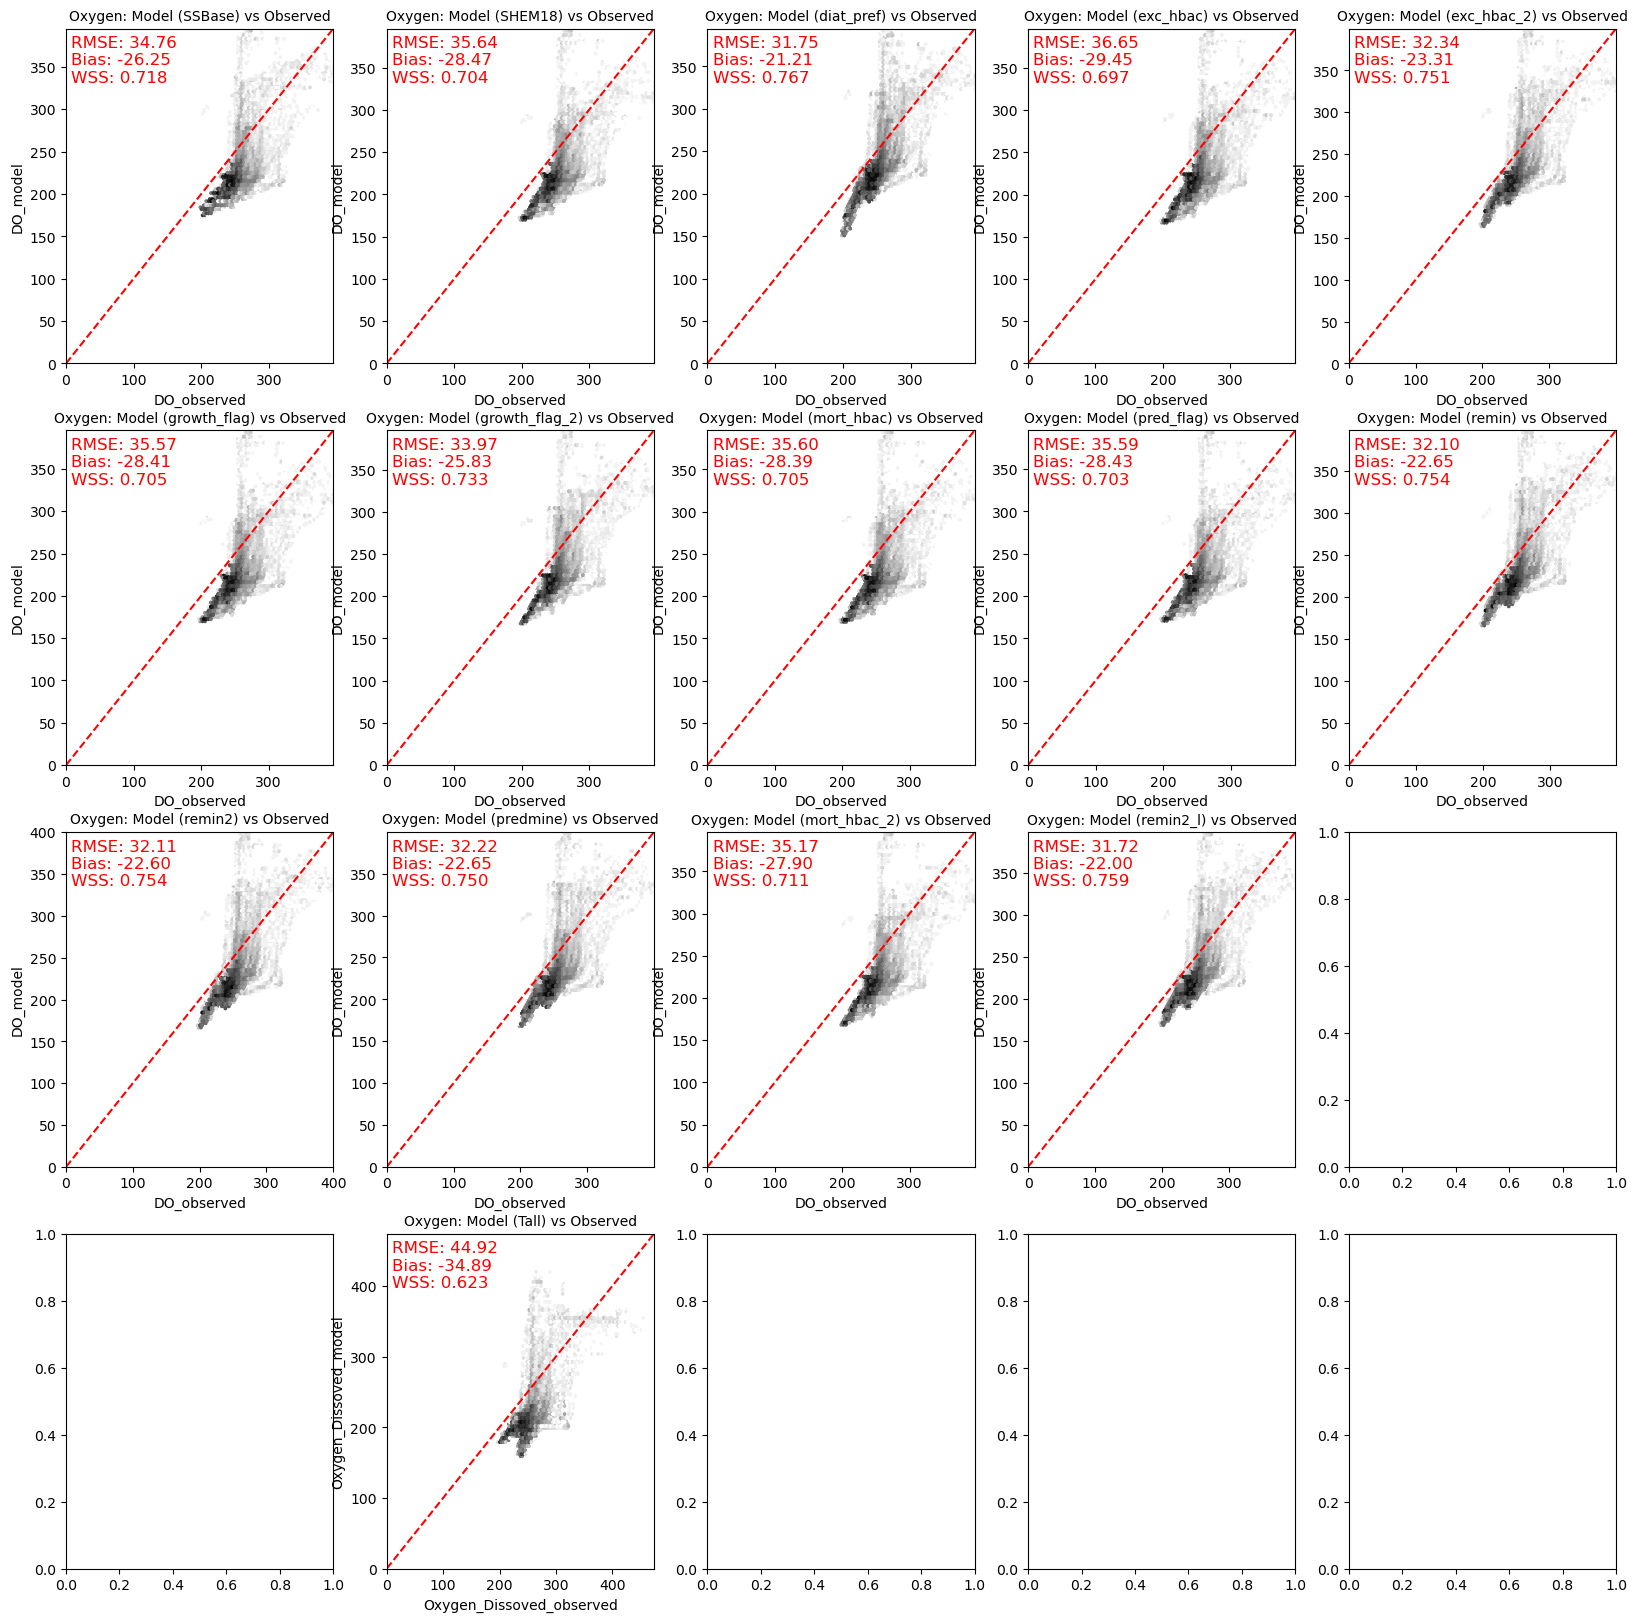

In [23]:
mask_N = (df_tall.mod_dissolved_oxygen> 0) & (~df_tall.Oxygen_Dissoved.isna())
rmse,bias,WI = calculate_rmse_bias(df_tall.Oxygen_Dissoved[mask_N]*31.25, df_tall.mod_dissolved_oxygen[mask_N])
axs_0[16].hexbin(df_tall.Oxygen_Dissoved*31.25, df_tall.mod_dissolved_oxygen, gridsize=80, norm=matplotlib.colors.LogNorm(), cmap='Greys')
axs_0[16].set_xlabel('Oxygen_Dissoved_observed')
axs_0[16].set_ylabel('Oxygen_Dissoved_model')
axs_0[16].set_title(f'Oxygen: Model (Tall) vs Observed')
axs_0[16].plot(np.linspace(0, max(df_tall.mod_dissolved_oxygen.max(), 31.25*df_tall.Oxygen_Dissoved.max()), 100), np.linspace(0, max(df_tall.mod_dissolved_oxygen.max(), 31.25*df_tall.Oxygen_Dissoved.max()), 100), 'r--') 
axs_0[16].set_xlim(0, max(df_tall.mod_dissolved_oxygen.max(), 31.25*df_tall.Oxygen_Dissoved.max()))
axs_0[16].set_ylim(0, max(df_tall.mod_dissolved_oxygen.max(), 31.25*df_tall.Oxygen_Dissoved.max()))
axs_0[16].text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=axs_0[16].transAxes,color='red')

fig_0

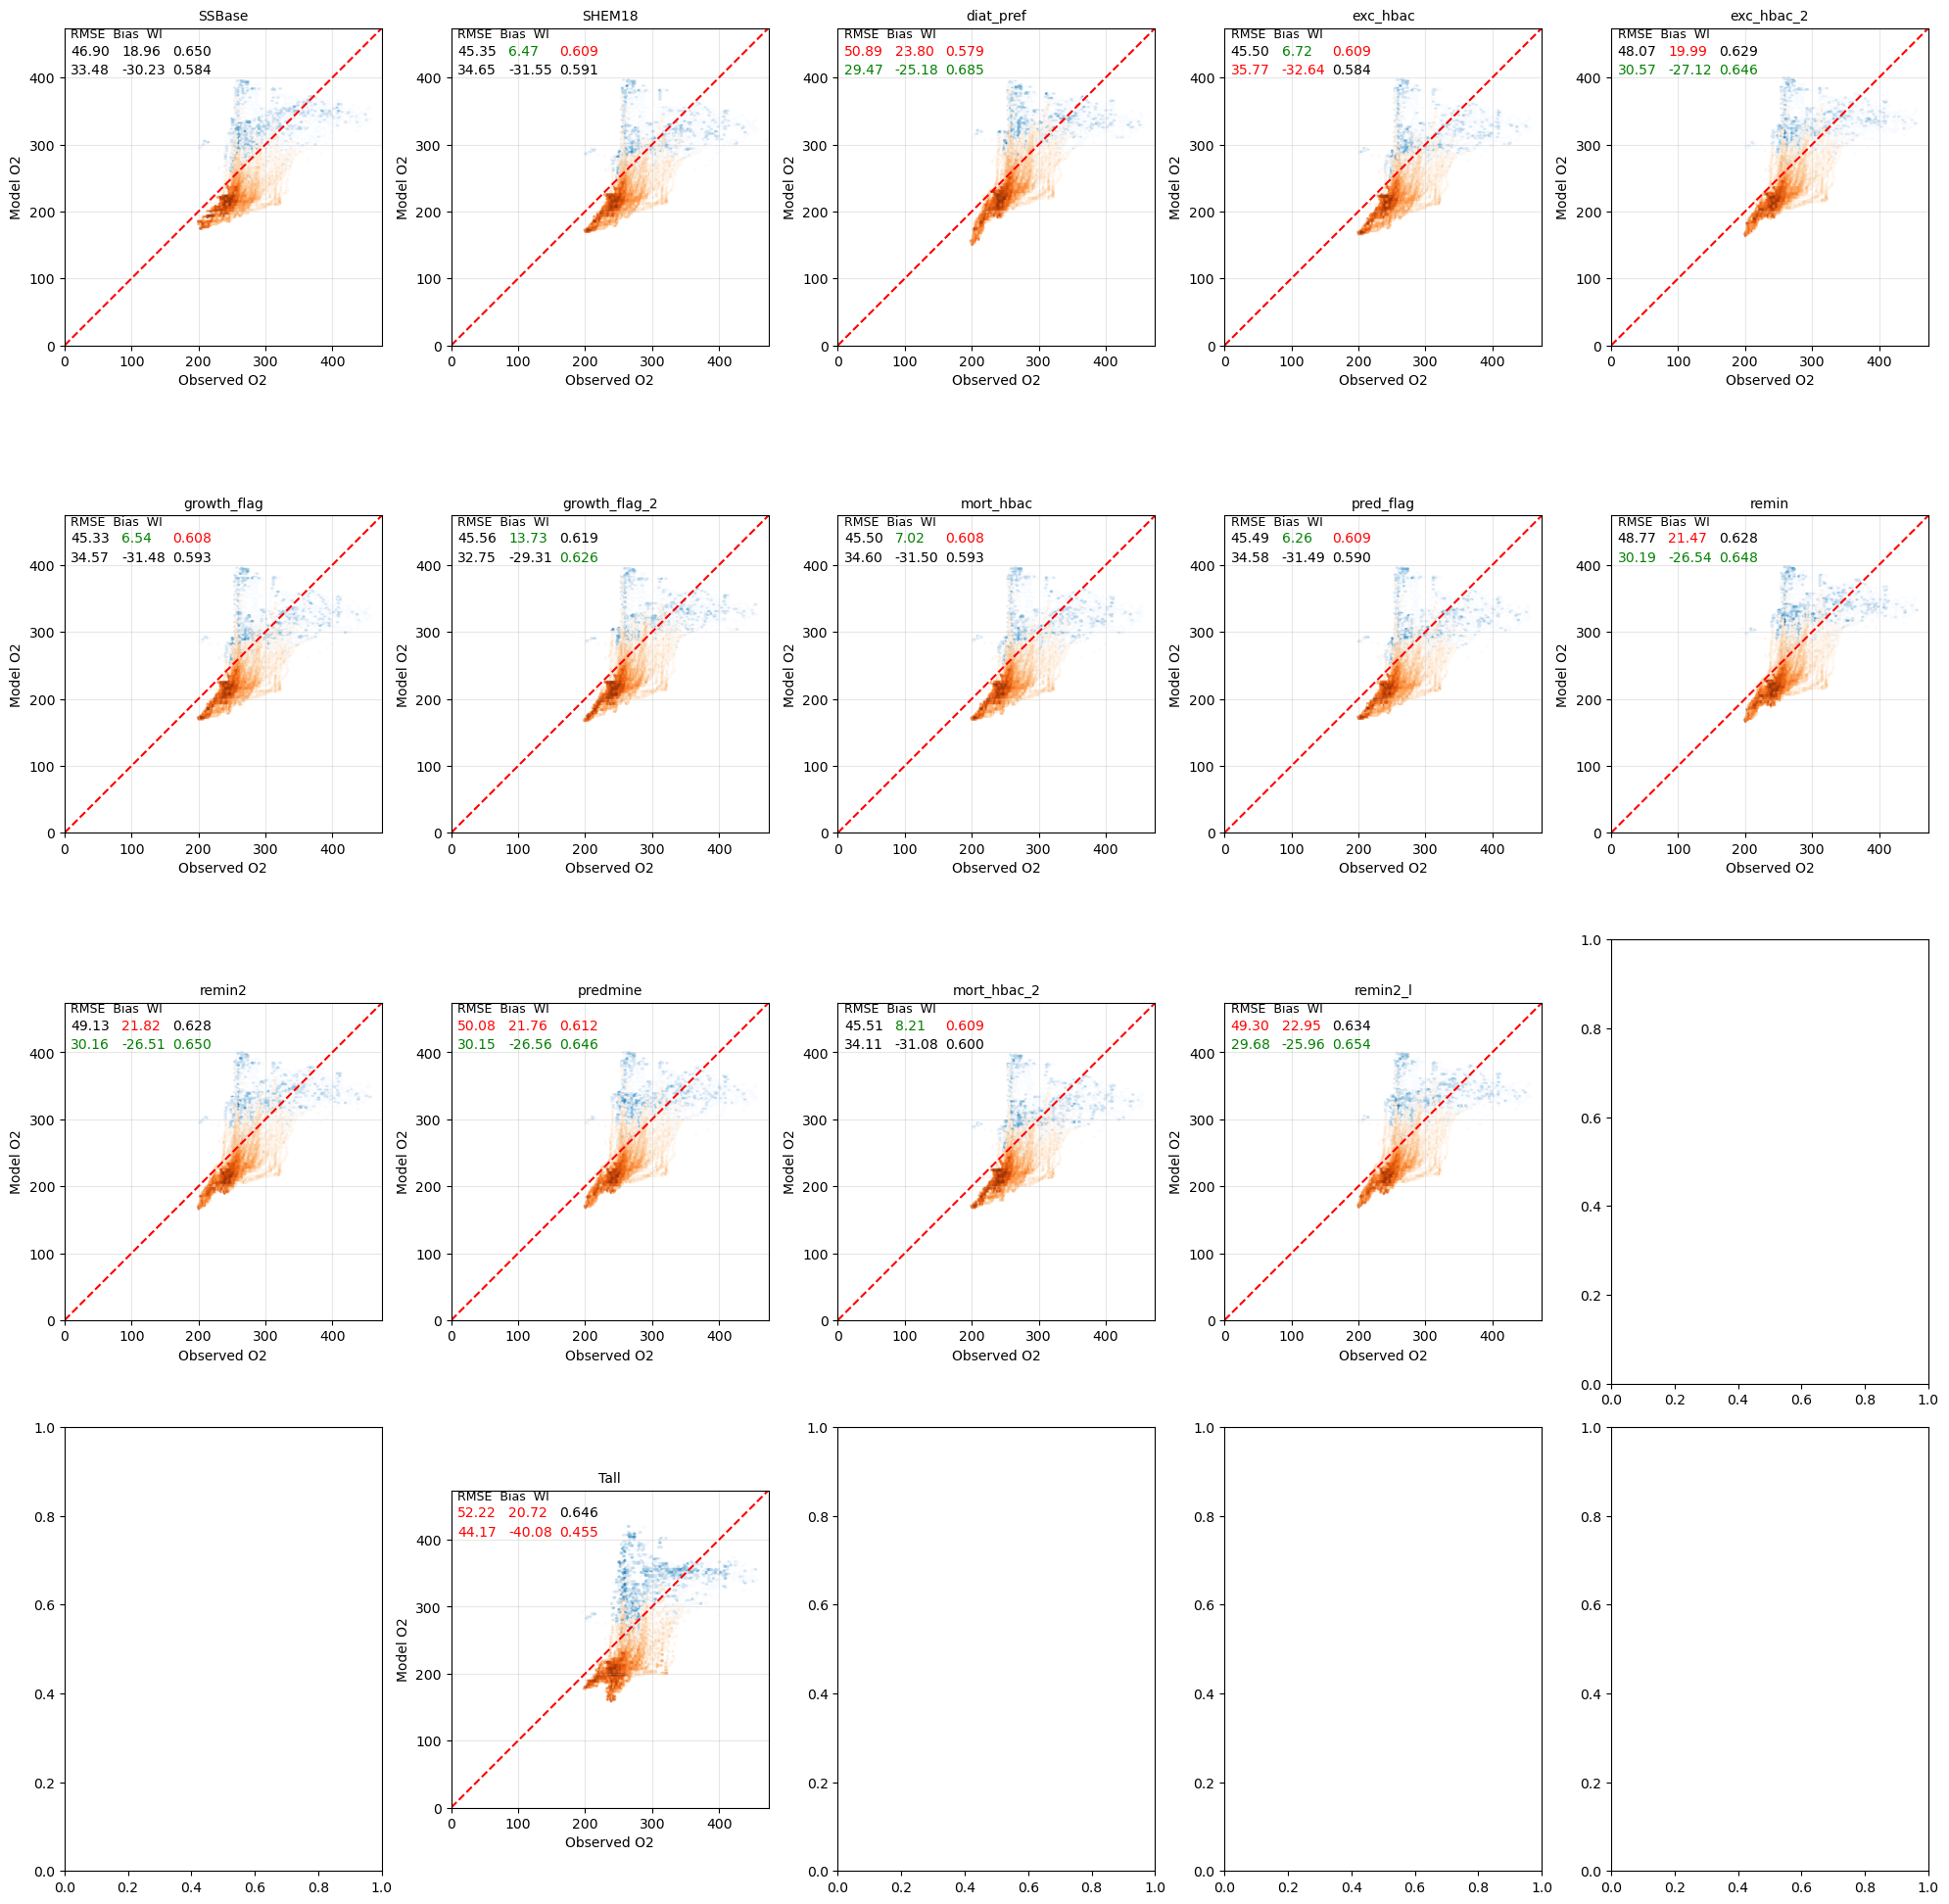

In [24]:
df_tall = pd.read_csv('ObsModel_202410b_PS_fromJose_20180101_20181231.csv', parse_dates=['dtUTC'], index_col=0)
df_tall = df_tall[(df_tall.index>=dt.datetime(2018,2,27))&(df_tall.index<=dt.datetime(2018,7,1))]
mb = (df_tall.mod_dissolved_oxygen> 0) & (~df_tall.Oxygen_Dissoved.isna())
stats = []

for j, ((d0, d1), cmap) in enumerate(zip(depth_limits, cmaps)):
    dm = mb & df_tall.Z.between(d0, d1, inclusive='left')
    if not dm.any():
        stats.append(("—","black","—","black"))
        continue

    hb = axs[16].hexbin(df_tall.Oxygen_Dissoved[dm]*31.25, df_tall.mod_dissolved_oxygen[dm],
                    gridsize=80, norm=mcolors.LogNorm(),
                    cmap=cmap, alpha=0.6, mincnt=1)

    rmse, bias, WI = calculate_rmse_bias(df_tall.Oxygen_Dissoved[dm]*31.25, df_tall.mod_dissolved_oxygen[dm])
    br, bb, bWI = baseline_stats[j]

    better_rmse = abs(rmse) <= abs(br) - abs(tol*br) 
    better_bias = abs(bias) <= abs(bb) - abs(tol*bb) 
    better_WI = WI >= bWI + tol*bWI 

    stats.append((
        f"{rmse:.2f}", "green" if better_rmse else("black" if abs(rmse) <= abs(br) + abs(tol*br) else "red") ,
        f"{bias:.2f}", "green" if better_bias else("black" if abs(bias) <= abs(bb) + abs(tol*bb) else "red") ,
        f"{WI:.3f}", "green" if better_WI else("black" if WI >= bWI - tol*bWI else "red")
    ))

if mb.any():
    mx = max(df_tall.mod_dissolved_oxygen[mb].max(), (df_tall.Oxygen_Dissoved[mb]*31.25).max())
    axs[16].plot([0,mx],[0,mx],'r--')
    axs[16].set(xlim=(0,mx), ylim=(0,mx), aspect='equal')

axs[16].set(title=f"Tall", xlabel="Observed O2", ylabel="Model O2")
axs[16].text(0.02,0.97,"RMSE  Bias  WI", transform=axs[16].transAxes, fontsize=9)

y = 0.95
for r, rc, b, bc, w, wc in stats:
    axs[16].text(0.02,y,r,color=rc,transform=axs[16].transAxes,va='top')
    axs[16].text(0.18,y,b,color=bc,transform=axs[16].transAxes,va='top')
    axs[16].text(0.34,y,w,color=wc,transform=axs[16].transAxes,va='top')
    y -= 0.06

axs[16].grid(alpha=0.3)
fig

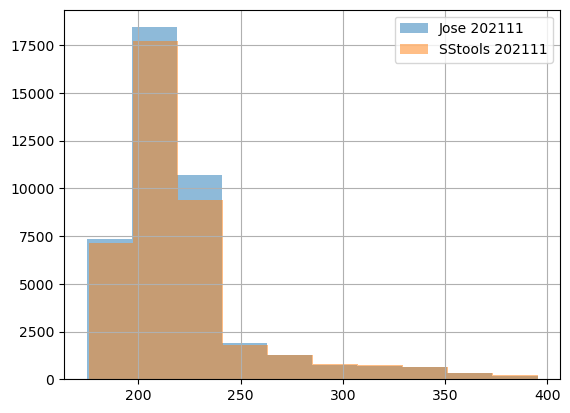

In [25]:
dfcompare = pd.read_csv(f'DO_puget_SSBase.csv', parse_dates=['Sample_Date'], index_col=0)
dfcompare = dfcompare[(dfcompare['Sample_Date']>=dt.datetime(2018,2,27))&(dfcompare['Sample_Date']<=dt.datetime(2018,7,1))]
mask_N = (dft.N_model!= 0) 
dfcompare = dfcompare[mask_N]
dfcompare.N_model.hist(alpha=0.5, label='Jose 202111')
df_tall_base.mod_dissolved_oxygen.hist(alpha=0.5, label='SStools 202111')
plt.legend()